<a href="https://colab.research.google.com/github/johnryantaylor/QCES/blob/main/Project3_tsunami.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Tsunami
In this project, we will use Dedalus to model the propagation of Tsunami waves. Tsunami typically have wavelengths larger than 100km and periods of about 1 hour. Since their wavelength is much larger than the depth of the ocean, Tsunami can be modelled using the shallow water equations. 

Here, we will use Dedalus to solve an initial value problem for the shallow water equations. We will generate a Tsunami using a localized disturbance to the water height. 

Student tasks are in [Section 1.3]( #section1pt3 ), [Section 2.3]( #section2pt3 ), and [Section 3.3]( #section3pt3 ).

## Setup
If you are using Google colab, run the script below to install Dedalus

In [1]:
# Set environment variables for best performance
%env OMP_NUM_THREADS=1
%env NUMEXPR_MAX_THREADS=1

# Minimize logging output
import logging
logging.disable(logging.DEBUG)

# Check if running on google colab
import os
using_google_colab = bool(os.getenv("COLAB_RELEASE_TAG"))

# Check for Dedalus
try:
    import dedalus.public as de
    print("Dedalus already installed :)")
except:
    print("Dedalus not installed yet.")
    if using_google_colab:
        print("Installing for Google Colab.")
        print()
        # Step 1: Install FFTW
        !apt-get install libfftw3-dev
        !apt-get install libfftw3-mpi-dev
        # Step 2: Set paths for Dedalus installation
        import os
        os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
        os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
        os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
        # Step 3: Install Dedalus using pip
        !pip3 install cython "mpi4py<4.0" numpy setuptools wheel
        !CC=mpicc pip3 install --no-cache --no-build-isolation http://github.com/dedalusproject/dedalus/zipball/master/
        !pip3 install -q ipympl
        # Step 4: Check installation
        print()
        try:
            import dedalus.public as de
            print("Dedalus successfully installed :)")
        except:
            print("Error installing Dedalus :(")
            raise
    else:
        print("See website for installation instructions:")
        print("https://dedalus-project.readthedocs.io/en/latest/pages/installation.html")

# Setup interactive matplotlib
if using_google_colab:
    from google.colab import output
    output.enable_custom_widget_manager()

env: OMP_NUM_THREADS=1
env: NUMEXPR_MAX_THREADS=1
Dedalus already installed :)


## 1.  1D shallow water equations
Let's start by solving the shallow water equations in 1D with periodic boundary conditions in our spatial variable, $x$. The script below solves the following equations:

$$ \partial_t u + g \partial_x(h) = - u\partial_x u$$
$$ \partial_t h + \partial_x(Hu) = -\partial_x(hu)$$

In these equations, $g$ is the constant gravitational acceleration, $u$ is the velocity in the $x$ direction, $H$ is the resting height, and $h$ is the height of the free surface relative to $H$. Note that the terms on the right hand side are nonlinear in our dependent variables, and we will use an explicit timestepping method for these terms. Recall that Dedalus uses explicit timestepping for terms on the right hand side of the inputted equation.

Because we are interested in an application to Tsunami, we will solve the equations using dimensional variables. It is convenient to define simulation units at the start of the script so that we can be explicit about the units.

We will start with the following initial conditions:
$$ h=e^{-(x-x_1)^2/w_1^2} $$
$$ u=0 $$
where $x_1$ is the center and $w_1=100$ km is the width of the Gaussian perturbation. 

To see how the waves change as they approach shallow water, we will set the resting water depth to include a localized seamount using the form:
$$ H=H_0-(H_0-H_{min})e^{(-(x-x_2)^2/w_2^2)} $$
where $x_2$ is the location of the seamount, $H_0=4$ km is the depth of the ocean away from the seamount, and $H_{min}$ is the minimum water depth above the seamount. Note that since $H\ll w$, the shallow water approximation is appropriate here.

### 1.1  Dedalus script to solve the 1D shallow water equations

The script below solves the 1D shallow water equations with the initial conditions given above.

In [2]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size
Nx = 512 # The number of gridpoints in x
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
w1 = 20 * kilometer # Width of the initial perturbation
x1 = 200 * kilometer # Center of the initial perturbation
x2 = 500 * kilometer # Center of the seamount
w2 = 100 * kilometer # Width of the seamount
H_min = 100 * meter # minimum depth above the seamount

timestep = 60 * second # Specify the timestep
stop_sim_time = 100 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Create an x-coordinate, a corresponding basis, and a distributor
xcoord = dedalus.Coordinate('x')
dist = dedalus.Distributor(xcoord, dtype=np.float64) # No mesh for serial / automatic parallelization
x_basis = dedalus.RealFourier(xcoord, size=Nx, bounds=(0, Lx))
x = dist.local_grid(x_basis)

# Specify the Fields and set the initial conditions
u = dist.Field(name='u', bases=x_basis)
h = dist.Field(name='h', bases=x_basis)
H = dist.Field(name='H', bases=x_basis)
h.change_scales(1) 
H.change_scales(1) 
u.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-(x-x2)**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2.0/w1**2.0)  # Initialize the height with a Gaussian function with width set above
u['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, xcoord)

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u)")
problem.add_equation("dt(h) + dx(H*u) = - dx(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

2025-11-13 14:15:00,624 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 4.5e+01/s
2025-11-13 14:15:00,631 __main__ 0/1 INFO :: Starting main loop
2025-11-13 14:15:00,711 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-13 14:15:00,712 solvers 0/1 INFO :: Final iteration: 100
2025-11-13 14:15:00,712 solvers 0/1 INFO :: Final sim time: 6000.0
2025-11-13 14:15:00,712 solvers 0/1 INFO :: Setup time (init - iter 0): 0.2409 sec
2025-11-13 14:15:00,713 solvers 0/1 INFO :: Warmup time (iter 0-10): 0.02591 sec
2025-11-13 14:15:00,713 solvers 0/1 INFO :: Run time (iter 10-end): 0.05469 sec
2025-11-13 14:15:00,713 solvers 0/1 INFO :: CPU time (iter 10-end): 1.519e-05 cpu-hr
2025-11-13 14:15:00,713 solvers 0/1 INFO :: Speed: 3.364e+06 mode-stages/cpu-sec


### 1.2  Plotting
The code below will make a movie of the height.

2025-11-13 14:15:00,776 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-13 14:15:00,777 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/m4/ngwxv9cj2ks_r_mpn8t3dzmh0000gn/T/tmp85s652t4/temp.m4v


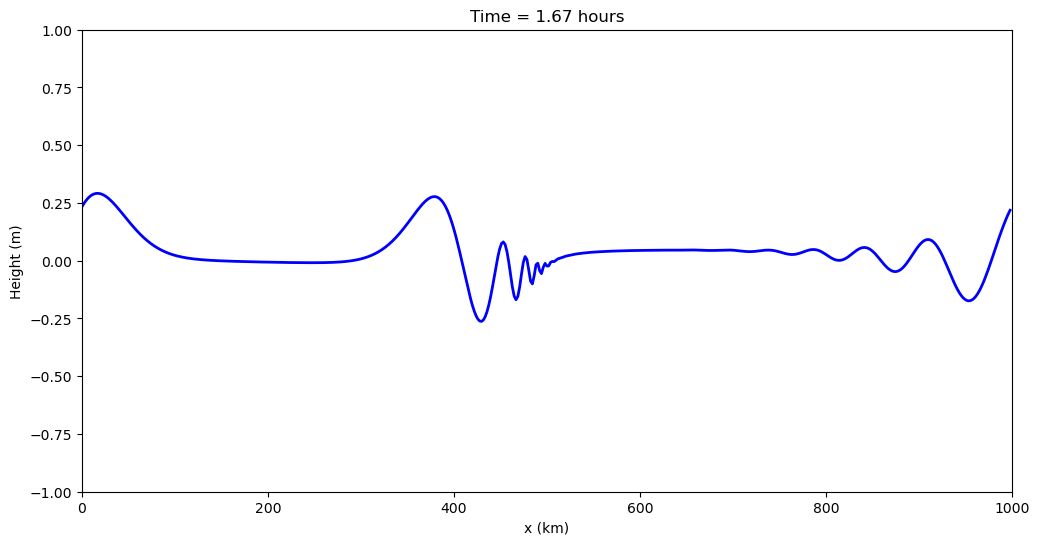

In [3]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Specify the axis limits and labels
plt.xlim((0, Lx / (1*kilometer)))            
plt.ylim((-1, 1))
plt.xlabel('x (km)')
plt.ylabel('Height (m)')

# Create objects that will change during the animation
txt_title = plt.title('')
height, = plt.plot([], [], 'b', lw=2)    

# Define an animation function
def drawframe(n):
    height.set_data(x/(1*kilometer), h_save[n,:])
    txt_title.set_text('Time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())


### 1.3 Student investigation
<a id='section1pt3'></a>
In the cells below, provide an expression for the expected wave speed and state any assumptions that are necessary to arrive at this. Then plot the wave speed from the output above and compare this with the expected value. 

ADD EXPRESSION FOR EXPECTED WAVE SPEED AND EXPLANATION HERE

The theoretical speed of shallow water waves is given by 
$$ c= \sqrt{gH} $$

This can be shown by manipulating the coupled PDEs 

$$ \partial_t u + g \partial_x(h) = - u\partial_x u$$
$$ \partial_t h + \partial_x(Hu) = -\partial_x(hu)$$

Perturbtion component of the variables:

h(x) = H + h', 

u = u'

We assume the perturbation in h is so much smaller than H such that
h << H, u' << u
and dh(x)/dt = 0

Diffrentiating the top equation w.r.t. t

$$ \partial_{tt} u + g \partial_{xt}(h) = 0$$
$$ \partial_t h = - \partial_x(Hu) $$

sub in the bottom equation into the top one

$$ \partial_{tt} u - gH \partial_{xx}(u) = 0$$

This is a wave equation with wave speed $$c = \sqrt{gH}$$

[]

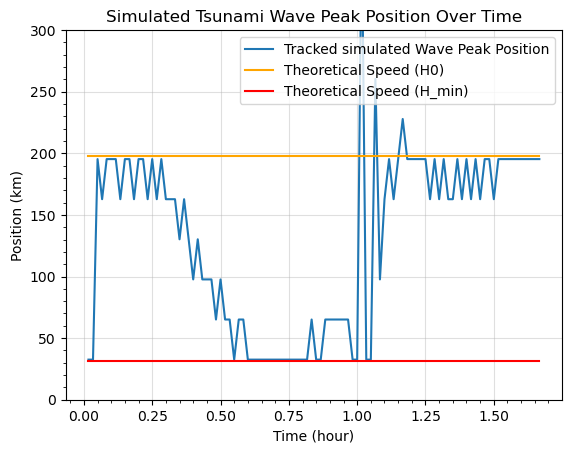

In [ ]:
# CREATE FIGURES HERE

# Simple rightward-only wave tracker (periodic)
import numpy as np

nt, Nx = h_save.shape
x1d = np.squeeze(x)

prev = int(np.argmax(h_save[0]))       # start at first-frame max
crest_idx = np.full(nt, -1, dtype=int)
crest_idx[0] = prev

def wrap_forward(a, b):
    # forward distance from b -> a in [0, Nx-1]
    return (a - b) % Nx

rel = 0.6            # 60% relative tolerance. This is a degree of freedom to be adjusted
abs_min = 1e-3        # minimum absolute tolerance (in simulation units)

for ti in range(nt):
    snapshot = h_save[ti]
    max_peak = snapshot.max()
    tol = max(abs_min, rel * abs(max_peak))
    ties = np.where(np.isclose(snapshot, max_peak, rtol=rel, atol=abs_min))[0]
    if ties.size == 1:
        chosen = ties[0]
    else:
        d = wrap_forward(ties, prev)
        ahead = ties[d > 0]
        if ahead.size:
            # choose nearest ahead (smallest positive forward distance)
            chosen = ahead[np.argmin(d[d > 0])]
        else:
            # no peak strictly ahead -> pick nearest in circular sense
            circ = np.abs(((ties - prev + Nx//2) % Nx) - Nx//2)
            chosen = ties[np.argmin(circ)]
    crest_idx[ti] = int(chosen)
    prev = int(chosen)

wave_peak_position = crest_idx
wave_peak_speed = np.diff(x1d[crest_idx]) / np.diff(t_save)   # optional speed (m/s)

theor_speed = np.sqrt(g* H0)
theor_speed_min = np.sqrt(g* H_min)

y_theor_speed = np.full_like(wave_peak_speed, theor_speed)
y_theor_speed_min = np.full_like(wave_peak_speed, theor_speed_min)

plt.plot(np.array(t_save[1:])/hour, wave_peak_speed, label='Tracked simulated Wave Peak Position')
plt.plot(np.array(t_save[1:])/hour, y_theor_speed, label='Theoretical Speed (H0)', c='orange')
plt.plot(np.array(t_save[1:])/hour, y_theor_speed_min, label='Theoretical Speed (H_min)', c='red')

plt.title('Simulated Tsunami Wave Peak Position Over Time')
plt.ylim(0,300)
plt.legend()
plt.minorticks_on()
plt.grid(alpha =0.4)
plt.xlabel('Time (hour)')
plt.ylabel('Position (km)')
plt.plot()

COMMENT ON RESULTS
#### Response

It can be seen that as the wave initially on average travels close to the threotetical speed of 190 m/s when it is over the open water. At time t=0.3h, wavepeak at x= 400, the wave starts to slow down and reached the minimum theoretical speed at t=0.6h when wavepeak is at x= 500, i.e. directly above the centre of the seamount. The wave speed starts to increase againn at t=1.0h (x=550). The wave speed to back to the initial theoretical speed again at t=1.2, that is when x=700 i.e. the wave back in the open water.

Note that the unphysical spikes at around t=1 are due to wave interfereance and the algorithm not being able to untangle the rightward moving wave clearly, so they should not be taken into consideration.

## 2.  2D Shallow water equations

Now, let's see how things change if we move to two dimensions. The script below solves the 2D shallow water equations:

$$ \partial_t u + g \partial_x(h) = - u*\partial_x u - v*\partial_y u$$
$$ \partial_t v + g \partial_y(h) = - u*\partial_x v - v*\partial_y v$$
$$ \partial_t h + \partial_x(u*H) + \partial_y(v*H)) = -\partial_x(h*u) - \partial_y(h*v)$$

We will initilize the Tsunami with the following equation 
$$ h=e^{-x^2/w_1^2} $$
$$ u=(g/c)*h $$

where $c=\sqrt{gH_0}$ and $H_0$ is the constant reference depth. The relationship between $u$ and $h$ follows from linearized shallow water equations and corresponds to a wave propagating in the $+x$ direction with a speed $c$.

We will solve the equations in a square domain with periodic boundary conditions and a Gaussian seamount in the middle of the domain with height

$$ H=H_{min}e^{-(x^2+y^2)/w_2^2} $$

The Tsunami should propagate with speed $c$ over the deep ocean where the depth is constant, but the wave will be modified as it passes over the seamount.

### 2.1  Dedalus script to solve the 2D shallow water equations

In [5]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 1 * kilometer # minimum depth above the seamount
w1 = 50 * kilometer # Set the width of the wave
w2 = 200 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 60 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

2025-11-13 14:15:19,972 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 15s, Remaining: 0s, Rate: 6.5e-02/s
2025-11-13 14:15:19,975 __main__ 0/1 INFO :: Starting main loop
2025-11-13 14:15:26,566 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-13 14:15:26,566 solvers 0/1 INFO :: Final iteration: 60
2025-11-13 14:15:26,567 solvers 0/1 INFO :: Final sim time: 3600.0
2025-11-13 14:15:26,567 solvers 0/1 INFO :: Setup time (init - iter 0): 15.38 sec
2025-11-13 14:15:26,567 solvers 0/1 INFO :: Warmup time (iter 0-10): 3.425 sec
2025-11-13 14:15:26,568 solvers 0/1 INFO :: Run time (iter 10-end): 3.166 sec
2025-11-13 14:15:26,568 solvers 0/1 INFO :: CPU time (iter 10-end): 0.0008795 cpu-hr
2025-11-13 14:15:26,568 solvers 0/1 INFO :: Speed: 3.761e+05 mode-stages/cpu-sec


### 2.2  Plotting
The code below will make a movie of the height as a function of x and y

2025-11-13 14:15:26,626 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-13 14:15:26,626 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 600x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/m4/ngwxv9cj2ks_r_mpn8t3dzmh0000gn/T/tmpk5p3zjkw/temp.m4v


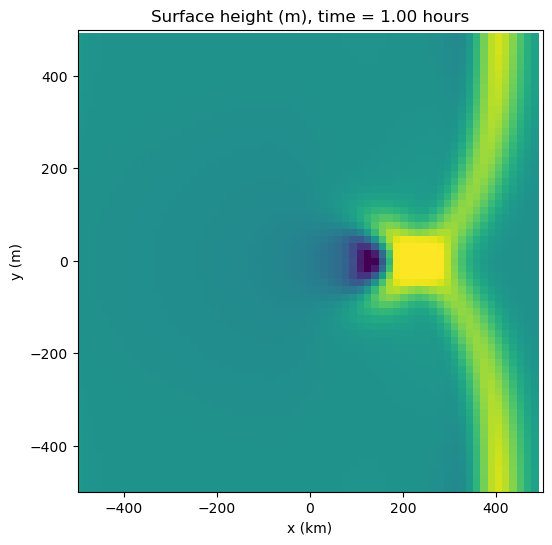

In [6]:
# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))   
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))            
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 2.3 Student investigation
<a id='section2pt3'></a>
Qualitatively describe the influence of the seamount and explain this behavior using the shallow water equations. You can assume that the wave amplitude and velocity are small in the shallow water equations.

STUDENT ANSWER HERE (~ 1 PARAGRAPH)

#### Response

The 2d shallow water wave behaves similarly as in the 1d case. As the wave passes over the seamount, its wave speed decreases, which can be seen from the relation $c \sim \sqrt{H_0}$. 
with the assumption of small amplitude and velocity, we may interpret that $$ \partial_t h = - \partial_x(u*H) - \partial_y(v*H) $$
and 
$$ \partial_t u = - g \partial_x(h). $$

This indicates that as the wave goes over an seamount to the plus x direction, the water depth the waves experiences will decrease, so \partial_x(H) is negative. Hence, h will increase with time. By the second equation, if h increases as the wave travels towards to the right, \partial_x(h) is positive and therefore partial u over partial t will be positive, implying the wave should deccelerate.

This indeed matches with our observation:

The wave appears to be "dragged" by the seamount because of this. Because the section of the wave which encountered the seamount now spreads over a larger region, from our observation and conservation of energy, the wave height/ amplitude is lowered.

However, the amplitude at y=0 appears to have became maximum. Using the same analysis for U field, the same analysis can be done to the y direction (V field), explaining why there seems to be a inward migration of the wave height maxima.
Interestingly after the wave passed the seamount, there appears to be trough left behind the wave peak. 

Try varying some parameters (e.g. the width and height of the wave and/or seamount) and comment on the results. When does the wave no longer obey the linear shallow water equations which are valid for small waves You don't need to do a comprehensive parameter space search, but you should run several simulations with one or two parameters varied.

2025-11-13 15:21:42,511 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 12s, Remaining: 0s, Rate: 8.4e-02/s
2025-11-13 15:21:42,516 __main__ 0/1 INFO :: Starting main loop
2025-11-13 15:21:49,851 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-13 15:21:49,852 solvers 0/1 INFO :: Final iteration: 60
2025-11-13 15:21:49,853 solvers 0/1 INFO :: Final sim time: 3600.0
2025-11-13 15:21:49,853 solvers 0/1 INFO :: Setup time (init - iter 0): 11.98 sec
2025-11-13 15:21:49,853 solvers 0/1 INFO :: Warmup time (iter 0-10): 3.769 sec
2025-11-13 15:21:49,853 solvers 0/1 INFO :: Run time (iter 10-end): 3.567 sec
2025-11-13 15:21:49,854 solvers 0/1 INFO :: CPU time (iter 10-end): 0.0009907 cpu-hr
2025-11-13 15:21:49,854 solvers 0/1 INFO :: Speed: 3.338e+05 mode-stages/cpu-sec
2025-11-13 15:21:49,891 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-13 15:21:49,892 matplotlib.animation 0/1 INFO :: MovieWriter._r

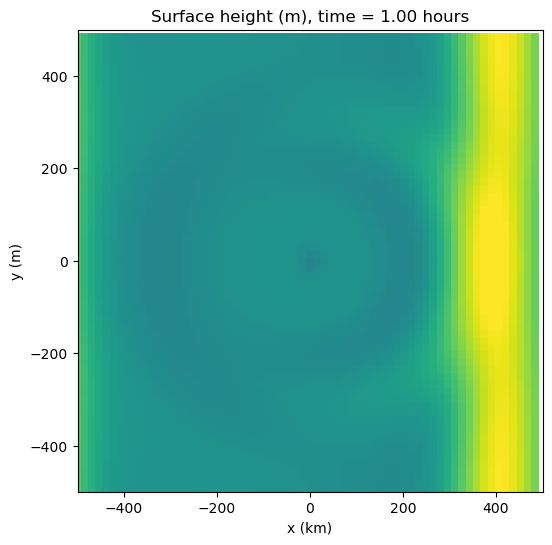

In [14]:
# ADD CODE AND PLOTS HERE
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 0.1 * kilometer # minimum depth above the seamount
w1 = 100 * kilometer # Set the width of the wave
w2 = 50 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 60 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))   
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))            
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

2025-11-18 12:16:03,840 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 13s, Remaining: 0s, Rate: 7.8e-02/s
2025-11-18 12:16:03,853 __main__ 0/1 INFO :: Starting main loop
2025-11-18 12:16:10,739 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-18 12:16:10,739 solvers 0/1 INFO :: Final iteration: 60
2025-11-18 12:16:10,740 solvers 0/1 INFO :: Final sim time: 3600.0
2025-11-18 12:16:10,740 solvers 0/1 INFO :: Setup time (init - iter 0): 12.81 sec
2025-11-18 12:16:10,740 solvers 0/1 INFO :: Warmup time (iter 0-10): 3.698 sec
2025-11-18 12:16:10,741 solvers 0/1 INFO :: Run time (iter 10-end): 3.188 sec
2025-11-18 12:16:10,741 solvers 0/1 INFO :: CPU time (iter 10-end): 0.0008855 cpu-hr
2025-11-18 12:16:10,741 solvers 0/1 INFO :: Speed: 3.735e+05 mode-stages/cpu-sec
2025-11-18 12:16:10,796 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-18 12:16:10,797 matplotlib.animation 0/1 INFO :: MovieWriter._r

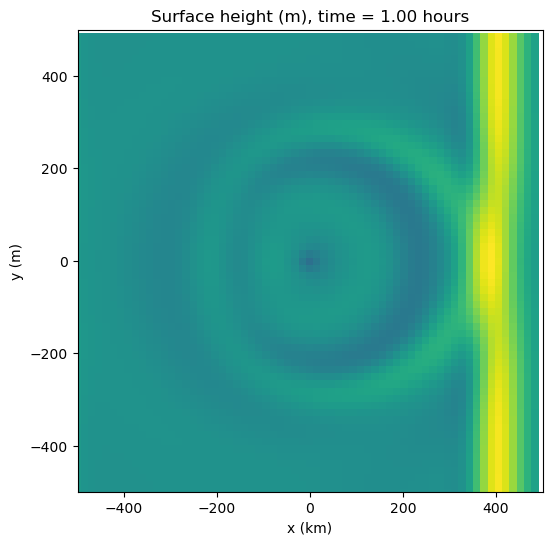

In [13]:
# ADD CODE AND PLOTS HERE
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 0.05 * kilometer # minimum depth above the seamount
w1 = 50 * kilometer # Set the width of the wave
w2 = 50 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 60 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))   
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))            
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

2025-11-13 14:55:26,068 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 21s, Remaining: 0s, Rate: 4.9e-02/s
2025-11-13 14:55:26,073 __main__ 0/1 INFO :: Starting main loop
2025-11-13 14:55:36,367 solvers 0/1 INFO :: Simulation stop time reached.
2025-11-13 14:55:36,368 solvers 0/1 INFO :: Final iteration: 120
2025-11-13 14:55:36,368 solvers 0/1 INFO :: Final sim time: 7200.0
2025-11-13 14:55:36,369 solvers 0/1 INFO :: Setup time (init - iter 0): 20.63 sec
2025-11-13 14:55:36,369 solvers 0/1 INFO :: Warmup time (iter 0-10): 2.961 sec
2025-11-13 14:55:36,369 solvers 0/1 INFO :: Run time (iter 10-end): 7.334 sec
2025-11-13 14:55:36,370 solvers 0/1 INFO :: CPU time (iter 10-end): 0.002037 cpu-hr
2025-11-13 14:55:36,370 solvers 0/1 INFO :: Speed: 3.572e+05 mode-stages/cpu-sec
2025-11-13 14:55:36,412 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-13 14:55:36,413 matplotlib.animation 0/1 INFO :: MovieWriter._r

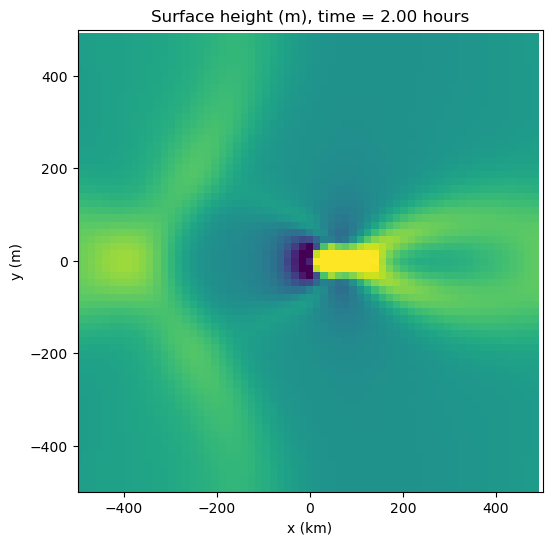

In [10]:
# ADD CODE AND PLOTS HERE
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Specify the simulation parameters
Lx = 1000 * kilometer # The domain size in x
Ly = 1000 * kilometer # The domain size in y
Nx = 64 # The number of gridpoints in x
Ny = 64 # The number of gridpoints in y
g = 9.81 * meter / second**2 # Gravitational acceleration
H0 = 4 * kilometer # Reference ocean depth
c = np.sqrt(g*H0) # Wave speed over the deep ocean
H_min = 0.05 * kilometer # minimum depth above the seamount
w1 = 100 * kilometer # Set the width of the wave
w2 = 500 * kilometer # Width of the seamount
x1 = -300 * kilometer # Center of the wave at t=0

timestep = 60 * second # Specify the timestep
stop_sim_time = 120 * minute # Specify the stopping time

timestepper = dedalus.RK222
max_timestep = 0.125

# Bases
coords = dedalus.CartesianCoordinates('x', 'y')
dist = dedalus.Distributor(coords, dtype=np.float64)
xbasis = dedalus.RealFourier(coords['x'], size=Nx, bounds=(-Lx/2, Lx/2), dealias=3/2)
ybasis = dedalus.RealFourier(coords['y'], size=Ny, bounds=(-Ly/2, Ly/2), dealias=3/2)

x, y = dist.local_grids(xbasis, ybasis)

# Fields
u = dist.Field(name='u', bases=(xbasis, ybasis))
v = dist.Field(name='v', bases=(xbasis, ybasis))
h = dist.Field(name='h', bases=(xbasis, ybasis))
H = dist.Field(name='H', bases=(xbasis, ybasis))

# Initial conditions
H.change_scales(1)
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
v.change_scales(1)
H['g'] = H0-(H0-H_min)*np.exp(-x**2.0/w2**2.0 - y**2.0/w2**2.0)
h['g'] = np.exp(-(x-x1)**2/w1**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
u['g'] = (g/c)*h['g']
v['g'] = 0

# Operators
dx = lambda a: dedalus.Differentiate(a, coords['x'])
dy = lambda a: dedalus.Differentiate(a, coords['y'])

# Problem
problem = dedalus.IVP([u, v, h], namespace=locals())
problem.add_equation("dt(u) + g*dx(h) = - u*dx(u) - v*dy(u)")
problem.add_equation("dt(v) + g*dy(h) = - u*dx(v) - v*dy(v)")
problem.add_equation("dt(h) + (dx(H*u) + dy(H*v)) = - dx(h*u) - dy(h*v)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=1*hour, max_writes=10)
snapshots.add_task(h, name='h')
snapshots.add_task(u, name='u')
snapshots.add_task(v, name='v')

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 1 == 0:
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save=np.array(h_save) # convert h_save to an np.array type to allow data slicing

# create a figure and axes
fig = plt.figure(figsize=(6,6))

# Create arrays with the x and y coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(x), np.squeeze(y))  

# Define an animation function
def drawframe(n):
    plt.clf # clear the figure before plotting the next frame
    height = plt.pcolor(X/(1*kilometer), Y/(1*kilometer), h_save[n,:,:].T, vmin=-1, vmax=1)
    # Specify the axis limits and labels
    plt.xlim((-Lx/2 / (1*kilometer),Lx/2 / (1*kilometer)))   
    plt.ylim((-Ly/2 / (1*kilometer),Ly/2 / (1*kilometer)))            
    plt.xlabel('x (km)')
    plt.ylabel('y (m)')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

STUDENT ANSWER HERE (~ 1 PARAGRAPH)

When does the wave no longer obey the linear shallow water equations which are valid for small waves?

A combination of change in wave width and seamount width does not seem to change the behaviour of the wave much. We have tried scenarios where the wave width is much larger than the seamount and where the wave width is much smaller than the seamount. 

We also note that when the wave width is too small, we see potential discretisation issues with Dedalus starting to occur.

A combination of wave width, seamount width and minimum water depth above the seamount that "breaks" the wave is 

wave width = 100 km

seamount width = 500 km

minimum water depth over the seamount = 0.05 km

suggesting the significant change in flow depth plays a predominant role in breaking the assumptions of the shallow water wave equation. We require a large change in the water depth and a wide seamount to break the shallow water wave behaviour.

This is because when H' (sea depth variation) is large as relative to the average sea (surface) depth, the terms $$ \partial_x(u*H) + \partial_y(v*H) $$ and especially the advection terms in the horizontal momentum equations can no longer be neglected, so the waves will behave non-linearly, i.e. slows down while not loosing amplitude and the wave will cease its forward motion completeley, as shown in the later timestep of the last simulation.  

## 3. Shallow water equations on a sphere

Of course the Earth isn't a flat plane. A great strength of Dedalus is its flexibility to solve equations in various geometries. The script below solves the 2D shallow water equations on a spherical shell, where the azimuth and colatitude are the independent variables. The colatitude is the complementary angle to the latitude such that the colatitude is $0^\circ$ at the North Pole, $90^\circ$ at the Equator, and $180^\circ$ at the South Pole. The spherical geometry also allows us to take into account the Earth's rotation in a realistic way. In this part of the project, we will assume that the bottom of the ocean is flat and that the resting height of the ocean is a constant $H$.  

We will use Dedalus to solve the following equations:
$$ \partial_t \mathbf{u} + g \nabla h + 2 \Omega \hat{\mathbf{z}} \times \mathbf{u} = -\mathbf{u} \cdot \nabla \mathbf{u} $$
$$ \partial_t + H \nabla \cdot \mathbf{u} = -\nabla \cdot (h \mathbf{u}) $$

where $\mathbf{u}$ is the velocity vector, $\Omega$ is the Earth's angular velocity (in radians per second), and $\hat{\mathbf{z}}$ is a unit vector aligned with the North Pole. Note that we have written the equations above in vector form. Dedalus includes vector calculus operators that make it very natural to solve equations like this without worrying about the particular form of the vector operators in a curvilinear coordinate system.

### 3.1  Dedalus script for 2D shallow water equations on a sphere

In [14]:
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians

timestep = 600 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)

# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
# Set the initial velocity to zero
u['g'][0] = 0 # the x-component of the velocity
u['g'][1] = 0 # the y-component of the velocity

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u)")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 4 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)

2025-11-18 13:46:52,505 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 1s, Rate: 1.0e+02/s
2025-11-18 13:46:52,543 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 0s, Rate: 1.5e+02/s
2025-11-18 13:46:52,602 subsystems 0/1 INFO :: Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 0s, Rate: 1.3e+02/s
2025-11-18 13:46:52,648 subsystems 0/1 INFO :: Building subproblem matrices 21/63 (~33%) Elapsed: 0s, Remaining: 0s, Rate: 1.4e+02/s
2025-11-18 13:46:52,687 subsystems 0/1 INFO :: Building subproblem matrices 28/63 (~44%) Elapsed: 0s, Remaining: 0s, Rate: 1.5e+02/s
2025-11-18 13:46:52,727 subsystems 0/1 INFO :: Building subproblem matrices 35/63 (~56%) Elapsed: 0s, Remaining: 0s, Rate: 1.5e+02/s
2025-11-18 13:46:52,767 subsystems 0/1 INFO :: Building subproblem matrices 42/63 (~67%) Elapsed: 0s, Remaining: 0s, Rate: 1.5e+02/s
2025-11-18 13:46:52,807 subsystems 0/1 INFO :: Building subproblem matri

### 3.2  Plotting
The code below will make a movie of the height as a function of x and y

2025-11-18 13:47:25,582 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-18 13:47:25,583 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/m4/ngwxv9cj2ks_r_mpn8t3dzmh0000gn/T/tmpstbxaeem/temp.m4v


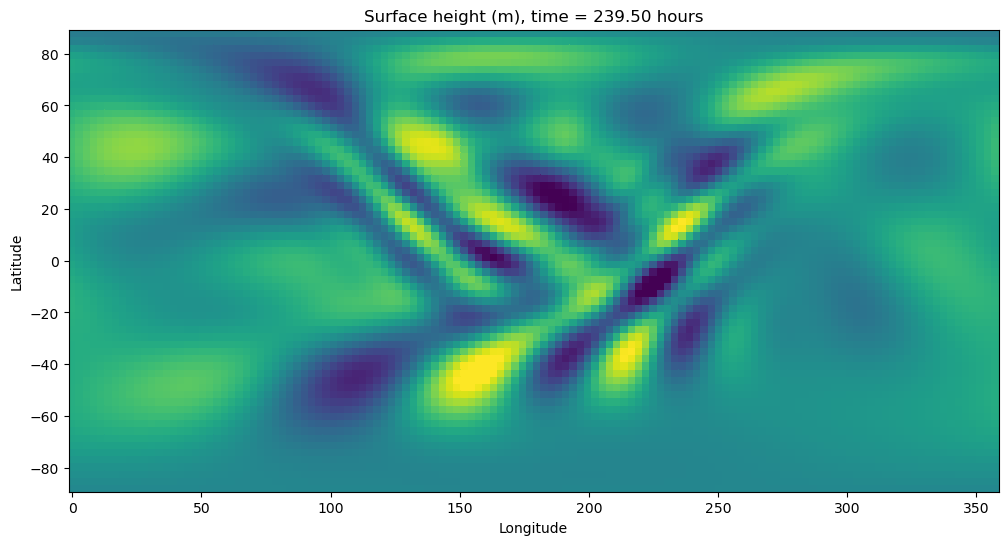

In [15]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)  

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels         
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

### 3.3 Student investigation
<a id='section3pt3'></a>
Create a virtual tide gauge by sampling the height at a point at a latitude of 45ºN and longitude of 90ºW and plot the timeseries of the height at this point in the cells below. You should modifty the code to save the height more often so that you can clearly see the shape of the wave. Notice that as the waves propagate around the Earth, their shape changes. Discuss physical mechanisms that might cause the shape of the wave to change as the wave propagates.

(361, 128, 64)
96 32
Time resolution: 600.0 seconds


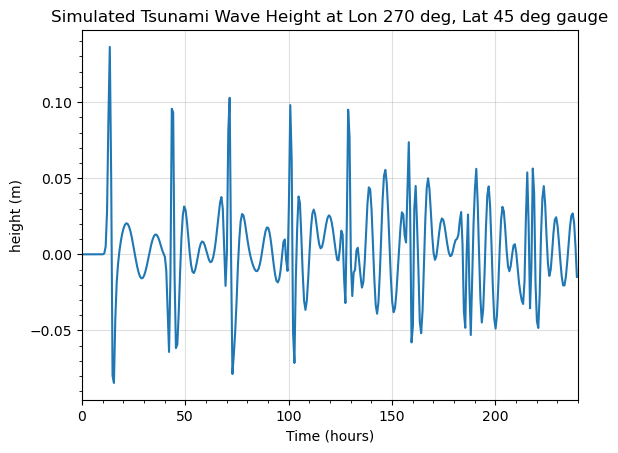

In [16]:
# Create a virtual gauge of wave height
print( h_save.shape) # here (timestep, longitude, latitude)
# Find the idex closest to the target long and lat
target_lon, target_lat = 270, 45 # 90 deg W is 270 deg latitude
lon_idx = np.argmin( np.abs( (phi*360/(2*np.pi)) - target_lon ) )
lat_idx = np.argmin( np.abs( ( (np.pi/2 - lat)*360/(2*np.pi) ) - target_lat ) )
print(lon_idx, lat_idx)
delta_t = t_save[1]-t_save[0]
print(f'Time resolution: {delta_t/second} seconds')
wave_height_gauge = h_save[:, lon_idx, lat_idx]
plt.plot( np.array(t_save)/hour, wave_height_gauge )
plt.title(f'Simulated Tsunami Wave Height at Lon {target_lon} deg, Lat {target_lat} deg gauge')
plt.xlabel('Time (hours)')
plt.ylabel('height (m)')
plt.xlim(0, stop_sim_time/hour)
plt.minorticks_on()
plt.grid(alpha=0.4)
plt.show()

We can see that there is a period of minimum local height variation of less than 0.05m in between period of large variations of 0.15m at earlier times (0 <t < 100hr). However, as time progress (t > 120 hrs), this resting period becomes less prominent as the height variation in this period becomes larger or are comparable to the larger variations. We can see that the large variations has period of around 25 hours.  

One reason why resting period is becoming increasingly filled with waves is because of the Coriolis effect on the travelling waves. As these waves travel a longer path, they will experience the rotation of Earth and will be deflected rather than travelling in a straight line. There is also a latitude dependence on the amount of Corilios force the wave will experience. These cause some of the waves to behave differently than described by the shallow water equations, some might propagate quicker (over a shorter path) and some slower. Combined with wave interfering and reflecting off with each other, these are the potential reasons why the waves would not converge back at the original point after they travelled around the globe once. This would also explain the wave activity in local height during the "resting" period.

Also in reality, this maybe due to the geometry of the Earth's being an oblate spheroid rather than a perfect sphere. However, this effect is small so may not be noticeable compared to Coriolis. We also note that this effect is not accounted in the code by Dedalus. 

We can also observe the maximum amplitudes of these waves decrease with time. This is not due to damping or energy loss, but due to more modes of waves being created and energy are spread to these waves (no energy can be created or destroyed). 

ADD PLOTS AND DISCUSSION HERE

In the simulation above, the Tsunami wave travels around the planet many times. In reality, the waves will partially dissipate when they reach shorelines. In the spherical shallow water equation code above (or in a new code block below), add a forcing term to the shallow water equations that damps the waves for longitudes larger than $\pm 90^\circ$. Specifically, add a forcing function to the right hand side of the height equation of the following form:

$$ - (1/\tau) f(\phi) h$$

where

$$ f(\phi) = \frac{1}{2}\left(1+tanh\left(\frac{\phi-3\pi/2}{\pi/10}\right)\right) + \frac{1}{2}\left(1-tanh\left(\frac{\phi-\pi/2}{\pi/10}\right)\right) $$

and $\phi$ is the co-latitude in radians and $\tau$ is a damping timescale. A timescale of $\tau=0.1$ days should be sufficient to damp the waves.

With this damping term active, much more slowly propagating waves should be visible. These are shallow water Rossby waves. Estimate the east/west phase speed of these Rossby waves from the theoretical dispersion relation and compare this estimate with the phase speed that you can infer from the simulation by plotting the height, $h$, as a function of longitude and time. Discuss the spatial structure of the Rossby waves and any discrepancies that you see between your estimated and measured phase speeds.

In [74]:
# Note that theta is the colatitude in our code, as opposed to the symbol used in the equation
# f = 0.5*(1+np.tanh((theta-(3*np.pi/2))/(np.pi/10)))+0.5*(1-np.tanh((theta-(np.pi/2))/(np.pi/10)))
# damping = -(1/tau)*f*h 

# ADD CODE HERE TO SOLVE THE SHALLOW WATER EQUATIONS WITH DAMPING.
# YOU CAN START BY COPYING THE CODE ABOVE AND PASTING IT HERE
# Import the required packages
# Import the required packages
import numpy as np
import dedalus.public as dedalus
import logging
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

# Define the simulation units. This is optional, but will help us keep track of units
meter = 1
kilometer = meter * 1e3
second = 1
minute = 60
hour = 3600
day = hour * 24

# Parameters
Nphi = 128 # Number of gridpoints in phi (longitude)
Ntheta = 64 # Number of gridpoints in theta (colatitude)
R = 6.37122e3 * kilometer
Omega = 2 * np.pi / (1 * day) # Earth's angular velocity in radians per second
g = 9.80616 * meter / second**2 # Gravitational acceleration
H = 4 * kilometer # Depth of the ocean
width = 2*np.pi*10/360 # Width of the initial Gaussian in radians
phi0 = np.pi # Longitude of the initial Gaussian height perturbation in radians
theta0 = np.pi/4 # Colatitude of the initial Gaussian height perturbation in radians

tau = 0.1*day  # damping timescale

timestep = 600 * second
stop_sim_time = 10 * day

# Bases
coords = dedalus.S2Coordinates('phi', 'theta')
dist = dedalus.Distributor(coords, dtype=np.float64)
basis = dedalus.SphereBasis(coords, (Nphi, Ntheta), radius=R, dealias=3/2, dtype=np.float64)

# Define the coordinates
phi, theta = dist.local_grids(basis) # Longitude and colatitude
lat = 360*(np.pi / 2 - theta)/(2*np.pi)  # latitude in degrees

# Fields
u = dist.VectorField(coords, name='u', bases=basis)
h = dist.Field(name='h', bases=basis)

# Set up a field for the damping term/ function
f = dist.Field(name='f', bases=basis)

# Operators
# First, create an operator to perform the cross product: "z x ", where z is the local vertical unit vector
# The "skew" operator performs a 90 degree rotation of a vector field,
# so that skew([u,v]) = [-v, u].  MulCosine multiplies by the cosine of the latitude
zcross = lambda A: dedalus.MulCosine(dedalus.skew(A))

# Set the initial conditions
h.change_scales(1) # Set values on regular grid
u.change_scales(1)
f.change_scales(1)
h['g'] = np.exp(-((phi-phi0)**2+(theta-theta0)**2)/width**2)  # Initialize the dependent variable c with a Gaussian function (note ** is the exponentiation operator)
# Set the initial velocity to zero
u['g'][0] = 0 # the x-component of the velocity
u['g'][1] = 0 # the y-component of the velocity

f_expression = 0.5*(1+np.tanh((theta-(3*np.pi/2))/(np.pi/10)))+0.5*(1-np.tanh((theta-(np.pi/2))/(np.pi/10)))

# Set up the damping function
f['g'] = f_expression

# Problem
problem = dedalus.IVP([u, h], namespace=locals())
problem.add_equation("dt(u) + g*grad(h) + 2*Omega*zcross(u) = - u@grad(u)")
problem.add_equation("dt(h) + H*div(u) = - div(h*u) - (1/tau)*f*h ")

# Solver
solver = problem.build_solver(dedalus.RK222)
solver.stop_sim_time = stop_sim_time

h.change_scales(1)
h_save = [np.copy(h['g'])]; t_save = [solver.sim_time]; # Save the initial condition and the initial time
# Main loop
try:
    logger.info('Starting main loop')
    while solver.proceed:
        solver.step(timestep)
        if (solver.iteration-1) % 4 == 0:
            logger.info('Iteration=%i, Time=%e, dt=%e' %(solver.iteration, solver.sim_time, timestep))
            h.change_scales(1)
            h_save.append(np.copy(h['g']))
            t_save.append(solver.sim_time)
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()

h_save = np.array(h_save)

2025-11-19 01:46:45,720 subsystems 0/1 INFO :: Building subproblem matrices 1/63 (~2%) Elapsed: 0s, Remaining: 0s, Rate: 2.5e+02/s
2025-11-19 01:46:45,737 subsystems 0/1 INFO :: Building subproblem matrices 7/63 (~11%) Elapsed: 0s, Remaining: 0s, Rate: 3.3e+02/s
2025-11-19 01:46:45,755 subsystems 0/1 INFO :: Building subproblem matrices 14/63 (~22%) Elapsed: 0s, Remaining: 0s, Rate: 3.5e+02/s
2025-11-19 01:46:45,774 subsystems 0/1 INFO :: Building subproblem matrices 21/63 (~33%) Elapsed: 0s, Remaining: 0s, Rate: 3.6e+02/s
2025-11-19 01:46:45,797 subsystems 0/1 INFO :: Building subproblem matrices 28/63 (~44%) Elapsed: 0s, Remaining: 0s, Rate: 3.4e+02/s
2025-11-19 01:46:45,817 subsystems 0/1 INFO :: Building subproblem matrices 35/63 (~56%) Elapsed: 0s, Remaining: 0s, Rate: 3.4e+02/s
2025-11-19 01:46:45,837 subsystems 0/1 INFO :: Building subproblem matrices 42/63 (~67%) Elapsed: 0s, Remaining: 0s, Rate: 3.5e+02/s
2025-11-19 01:46:45,856 subsystems 0/1 INFO :: Building subproblem matri

2025-11-19 01:47:02,869 matplotlib.animation 0/1 INFO :: Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-11-19 01:47:02,870 matplotlib.animation 0/1 INFO :: MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 1200x600 -pix_fmt rgba -framerate 25.0 -i pipe: -vcodec h264 -pix_fmt yuv420p -y /var/folders/m4/ngwxv9cj2ks_r_mpn8t3dzmh0000gn/T/tmpk4splllh/temp.m4v


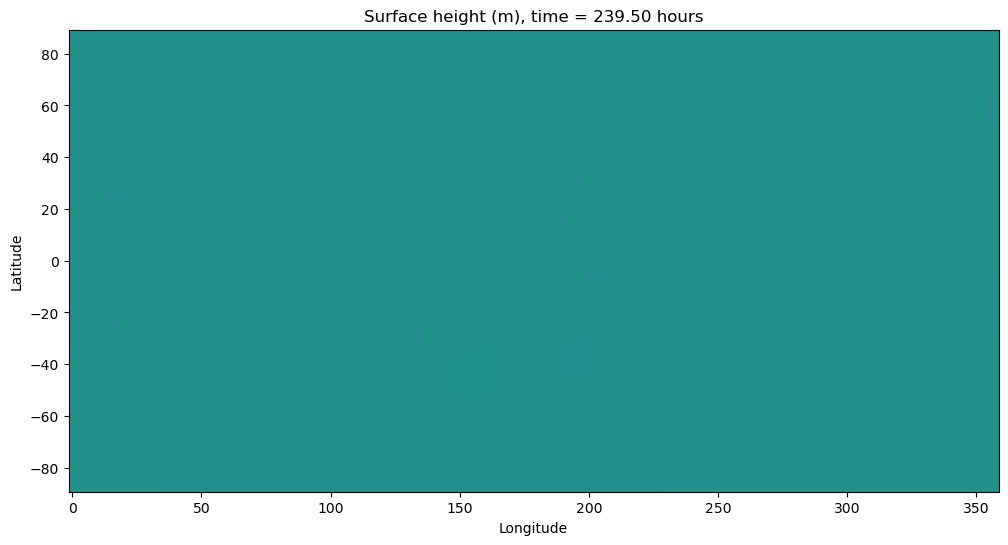

In [75]:
# create a figure and axes
fig = plt.figure(figsize=(12,6))

# Create arrays with the latitude and longitude coordinates for plotting using pcolor
from dedalus.extras import plot_tools
(X, Y) = plot_tools.quad_mesh(np.squeeze(np.pi/2 - theta)*360/2/np.pi, np.squeeze(phi)*360/2/np.pi)  

# Define an animation function
def drawframe(n):
    plt.clf()
    height = plt.pcolor(Y, X, h_save[n,:,:], vmin=-0.1, vmax=0.1)
    # Specify the axis limits and labels         
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Surface height (m), time = {0:.2f} hours'.format(t_save[n]/(1*hour)))
    return (height,)

from matplotlib import animation
# blit=True re-draws only the parts that have changed.
anim = animation.FuncAnimation(fig, drawframe, frames=len(t_save), interval=40, blit=True)

from IPython.display import HTML
HTML(anim.to_html5_video())

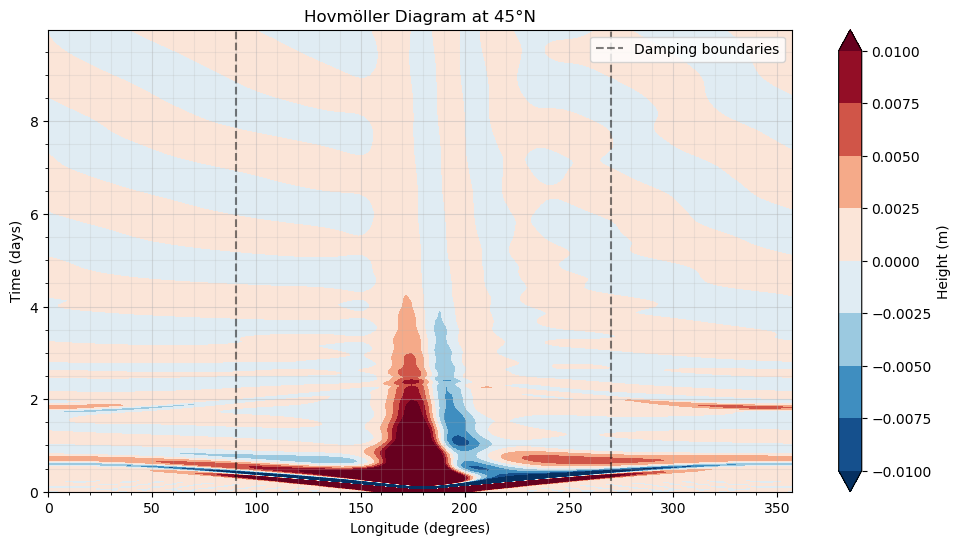

In [ ]:
# Extract data at fixed latitude (45°N)
lat_target = 45
lat_idx = np.argmin(np.abs((np.pi/2 - theta)*360/(2*np.pi) - lat_target))

# Plot height vs longitude and time
plt.figure(figsize=(12, 6))
# phi is 2D, but we only need the longitude values (first dimension)
lon_values = phi[:, 0] * 360 / (2*np.pi)  # Extract longitude from first column

levels = np.linspace(-0.01, 0.01, 9)  
plt.contourf(lon_values, np.array(t_save)/day, 
             h_save[:, :, lat_idx], levels=levels, cmap='RdBu_r', extend='both')
plt.colorbar(label='Height (m)')
plt.xlabel('Longitude (degrees)')
plt.ylabel('Time (days)')
plt.title(f'Hovmöller Diagram at {lat_target}°N')
plt.axvline(90, color='k', linestyle='--', alpha=0.5, label='Damping boundaries')
plt.axvline(270, color='k', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.minorticks_on()
plt.grid(which = 'major',alpha=0.4)
plt.grid(which = 'minor',alpha=0.2)
plt.show()

In [81]:
# Theorhetical Rossby wave speed 
# c_p = w/k = -beta/(k**2 + l**2 + f_0^2/(gH0))

# At 45N, 
lat_rad = np.pi/4

beta = 2*Omega*np.cos(lat_rad)/R  # beta at 45 degrees latitude
f0 = 2*Omega*np.sin(lat_rad)  # f at 45 degrees latitude
k = 1 / (R * np.cos(lat_rad)) # zonal wavenumber number 1, in rad/m
l = 0  # meridional wavenumber number 0, in rad/m, since Rossby wave primarily propagates zonally

c_p = -beta / (k**2 + l**2 + f0**2/(g*H0))

print(f'Rossby deformation radius at 45N: {np.sqrt(g*H0) / f0 / kilometer} km')
print(f'Theoretical Rossby wave phase speed at 45N: {c_p} m/s') # negative sign indicates westward propagation
# convert to longitude per day at at 45N
c_p_lon_per_day = c_p * day / (( 111.1*10**3 * np.cos(lat_rad))) # 1 degree of longitude = 111.1 km * cos(latitude)
print(f'Theoretical Rossby wave phase speed at 45N: {c_p_lon_per_day} degrees longitude per day')

Rossby deformation radius at 45N: 1925.7431400228409 km
Theoretical Rossby wave phase speed at 45N: -50.6143899802851 m/s
Theoretical Rossby wave phase speed at 45N: -55.66582992062566 degrees longitude per day


Averaging the 4 waves signals between day 4 to 8 over 0 to 90 and 270 to 360 deg longitude in the Hovmöller diagram, we acquire a(n average) wavespeed of 69 longitudes per day towards the west. This is slightly quicker than our theorhetical estimate of 56 longitudes per day. This might be due to the damping term causes the wave activity to cease between 90 to 270 deg. This can be seen in the Hovmöller diagram, where the wave one pattern seemingly breaks within the region with damping and as the Rossby waves enter the damping region, it seems to have slowed down very much by the "continents". The Rossby waves would not be able to communicate with the waves over the coast of the other side. Given this disorted pattern, we therefore should question what's an appropriate value for the wavenumber to calculate our theoretical phase speed and would not expect the measured speed to match exactly with the theoretical speed. 

The variation in height is subtle, with amplitude of only 0.005m = 0.5cm in the free surface, which matches with the expectation of a typical oceanic Rossby wave amplitude. We can therefore distinguish the initial shallow water Tsunami waves of higher amplitudes from the later Rossby waves. Hence, it can be said that the Tsunami waves have dissipated at or before day 2.

We note that the propagation of the Rossby waves slows down as time increases further as seen in the figure. This might be due to the creation of higher mode waves (wavenumber 2 or higher), which are of slower phase speeds. 

## 4. Optional further investigations

* In the example of the shallow water equations on a sphere, introduce bathymetry by making $H$ a function of latitude and longitude. Make sure that you modify the equations in Dedalus appropriately. How do the waves behave when they encounter shallow water (e.g. a localized seamount)?

* It is quite difficult to simulate changing sea level (sometimes called wetting and drying), which is why the examples above do not include land. However, we can estimate the distance that a Tsunami will propagate using physical and dimensional arguments. Consider, for example, a flat, sloping beach. In the absence of energy dissipation, estimate the distance that a wave will propagate onshore. How could you modify this estimate to include energy dissipation (or drag)?